<a href="https://colab.research.google.com/github/eyespydushyant/hotel-booking-price-prediction/blob/main/dushyant_Regression__ML_Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -



##### **Project Type**    - Regression
##### **Contribution**    - Individual


# **Project Summary -**

## Project Summary

The objective of this project was to develop a Machine Learning regression model capable of predicting the **Average Daily Rate (ADR)** of hotel bookings using historical booking data. ADR is one of the most important performance metrics in the hospitality industry, as it represents the average revenue earned for each occupied room. Accurate prediction of ADR enables hotels to optimize room pricing, improve revenue management, and make better business decisions based on customer demand and booking behavior.

The project began with understanding the dataset and identifying the target variable along with the input features that influence hotel room pricing. The dataset contained both numerical and categorical variables such as hotel type, lead time, arrival date details, number of adults, children and babies, meal type, market segment, distribution channel, reserved room type, assigned room type, previous cancellations, booking changes, customer type, and several other booking-related attributes. A detailed exploratory data analysis (EDA) was performed to understand the distribution of variables, identify missing values, detect outliers, and examine relationships between features and the target variable. Various visualizations such as histograms, box plots, correlation heatmaps, and scatter plots were used to gain meaningful insights into the data.

The preprocessing stage involved handling missing values, removing unnecessary columns, encoding categorical variables into numerical format, and scaling numerical features where required. Feature engineering and data cleaning improved the overall quality of the dataset and ensured that it was suitable for machine learning algorithms. The processed data was then divided into training and testing sets to evaluate model performance on unseen data.

Multiple regression models were developed and compared during this project. Initially, a baseline regression model was trained, followed by regularized regression models including Ridge Regression and Lasso Regression. To improve prediction performance, hyperparameter tuning techniques were applied. **GridSearchCV** was used to identify the optimal regularization parameter for Ridge Regression, while **RandomizedSearchCV** was applied to Lasso Regression to efficiently search for the best hyperparameter values. Cross-validation was incorporated during hyperparameter tuning to reduce overfitting and ensure that the selected models generalized well to unseen data.

The models were evaluated using standard regression metrics, including **Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score**. These metrics provided a comprehensive understanding of prediction accuracy and model performance. Lower values of MAE, MSE, and RMSE indicated smaller prediction errors, while a higher R² score demonstrated that the model explained a larger proportion of the variation in ADR. After comparing the performance of all models, the tuned **Ridge Regression** model produced the most balanced and reliable results, making it the final model for this project.

Model interpretation was also carried out by analyzing regression coefficients to understand the contribution of different features toward ADR prediction. Features such as hotel type, room type, lead time, market segment, and customer-related information were found to have a significant impact on room pricing. These insights can help hotel managers understand the major factors affecting revenue and design more effective pricing strategies.

Overall, this project demonstrates the complete machine learning workflow, including data preprocessing, exploratory data analysis, feature engineering, model development, hyperparameter optimization, model evaluation, and interpretation. The final regression model provides an effective solution for predicting hotel room prices and can support hotels in improving pricing strategies, increasing revenue, and making informed business decisions through data-driven insights.


# **GitHub Link -**

https://github.com/eyespydushyant/hotel-booking-price-prediction

# **Problem Statement**


## Problem Statement

In the hospitality industry, determining the appropriate room price is a challenging task because it depends on multiple factors such as hotel type, booking lead time, room type, market segment, customer preferences, seasonality, and booking behavior. Hotels often face difficulties in setting competitive room prices that maximize occupancy while maintaining profitability. Incorrect pricing strategies can result in revenue loss, reduced customer satisfaction, and inefficient resource utilization.

The objective of this project is to build a Machine Learning regression model that accurately predicts the **Average Daily Rate (ADR)** of hotel bookings using historical booking data. The dataset contains various booking-related features, including customer information, reservation details, room allocation, booking changes, and market characteristics. By analyzing these factors, the model aims to identify the key variables that influence ADR and generate reliable price predictions.

The developed model will help hotel management make data-driven pricing decisions, optimize revenue management strategies, improve forecasting accuracy, and better understand the factors affecting hotel room prices. The project's ultimate goal is to provide an accurate and interpretable predictive model that supports efficient pricing decisions and enhances overall business performance.


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 5.0 MB/s eta 0:00:00


In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
from skopt import BayesSearchCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

### Dataset Loading

In [ ]:
# Load Dataset
df = pd.read_csv("/content/hotel_bookings.csv")

### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows : 119390
Columns : 32


### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 31994


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

missing.sort_values("Missing Values",ascending=False)

,Missing Values,Percentage
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00
arrival_date_month,0,0.00
arrival_date_week_number,0,0.00
hotel,0,0.00
is_canceled,0,0.00
stays_in_weekend_nights,0,0.00
arrival_date_day_of_month,0,0.00


In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 31994


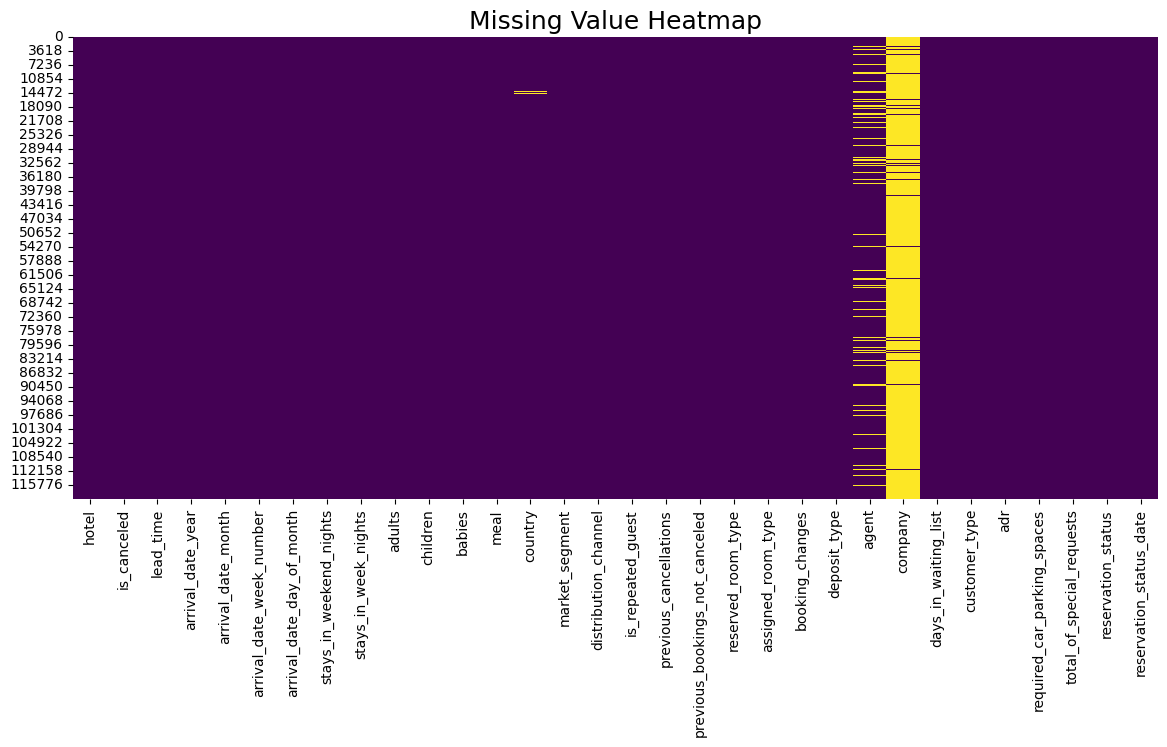

In [ ]:
# Visualizing the missing values
plt.figure(figsize=(14,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Value Heatmap",fontsize=18)

plt.show()

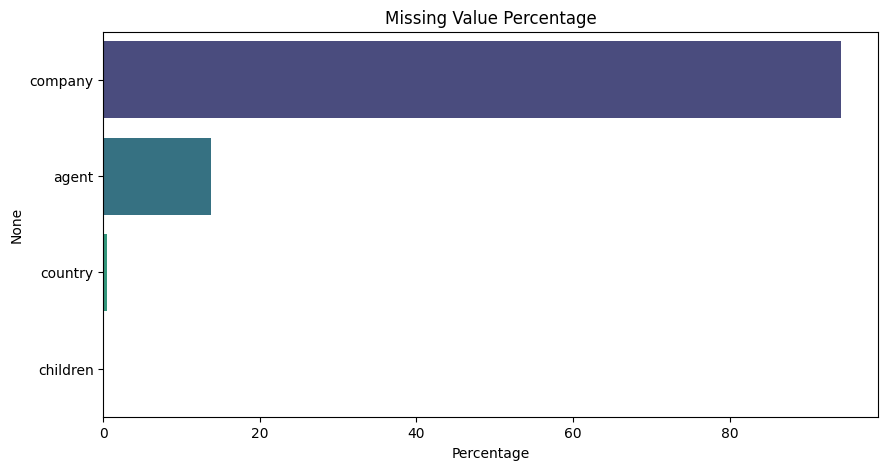

In [ ]:
missing_percent=df.isnull().mean()*100

missing_percent=missing_percent[missing_percent>0]

missing_percent=missing_percent.sort_values(ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(x=missing_percent.values,
            y=missing_percent.index,
            palette="viridis")

plt.xlabel("Percentage")

plt.title("Missing Value Percentage")

plt.show()

### What did you know about your dataset?

The dataset used in this project is the Hotel Booking Demand Dataset, which contains booking information for both City Hotels and Resort Hotels. It includes various customer details, reservation information, hotel characteristics, and booking status. The primary goal of this project is to predict the Average Daily Rate (ADR), making it a supervised machine learning regression problem.

The dataset consists of 119,390 rows and 32 columns, providing a large amount of historical booking data suitable for predictive analysis. It contains both numerical and categorical features such as hotel type, lead time, arrival date, number of adults, children, babies, meal type, country, market segment, distribution channel, room type, deposit type, customer type, previous cancellations, booking changes, special requests, parking requirements, and ADR.

During the initial exploration, it was observed that some columns contained missing values, particularly children, country, agent, and company. The dataset also contained duplicate records, which were removed during preprocessing to improve data quality. Additionally, a few numerical features, especially ADR and Lead Time, contained outliers that required careful analysis.

Since the target variable ADR (Average Daily Rate) is continuous, this problem is classified as a regression problem. Before building the machine learning models, several preprocessing techniques such as handling missing values, removing duplicates, feature engineering, encoding categorical variables, and feature scaling were applied to prepare the dataset.

The objective of this project is to build and compare multiple regression models to accurately predict hotel room prices (ADR). The insights obtained from this analysis can help hotels optimize their pricing strategies, improve revenue management, and make data-driven business decisions.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [ ]:
# Dataset Describe
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


### Variables Description

| Variable                           | Description                                                                              |
| ---------------------------------- | ---------------------------------------------------------------------------------------- |
| **hotel**                          | Type of hotel (Resort Hotel or City Hotel).                                              |
| **is_canceled**                    | Indicates whether the booking was canceled (1 = Yes, 0 = No).                            |
| **lead_time**                      | Number of days between the booking date and the arrival date.                            |
| **arrival_date_year**              | Year of arrival.                                                                         |
| **arrival_date_month**             | Month of arrival.                                                                        |
| **arrival_date_week_number**       | Week number of the arrival date.                                                         |
| **arrival_date_day_of_month**      | Day of the month on which the guest arrived.                                             |
| **stays_in_weekend_nights**        | Number of weekend nights (Saturday or Sunday) booked.                                    |
| **stays_in_week_nights**           | Number of weekday nights booked.                                                         |
| **adults**                         | Number of adults included in the booking.                                                |
| **children**                       | Number of children included in the booking.                                              |
| **babies**                         | Number of babies included in the booking.                                                |
| **meal**                           | Type of meal package booked (BB, HB, FB, etc.).                                          |
| **country**                        | Country of origin of the customer.                                                       |
| **market_segment**                 | Market segment through which the booking was made.                                       |
| **distribution_channel**           | Booking distribution channel (Direct, TA/TO, Corporate, etc.).                           |
| **is_repeated_guest**              | Indicates whether the customer is a repeated guest.                                      |
| **previous_cancellations**         | Number of previous bookings canceled by the customer.                                    |
| **previous_bookings_not_canceled** | Number of previous bookings completed without cancellation.                              |
| **reserved_room_type**             | Room type reserved by the customer.                                                      |
| **assigned_room_type**             | Room type actually assigned to the customer.                                             |
| **booking_changes**                | Number of changes made to the booking before arrival.                                    |
| **deposit_type**                   | Type of deposit made (No Deposit, Refundable, Non Refund).                               |
| **agent**                          | ID of the travel agent who made the booking.                                             |
| **company**                        | ID of the company responsible for the booking.                                           |
| **days_in_waiting_list**           | Number of days the booking remained on the waiting list.                                 |
| **customer_type**                  | Type of customer (Transient, Contract, Group, etc.).                                     |
| **adr**                            | **Average Daily Rate (Target Variable)** – Average room price per occupied room per day. |
| **required_car_parking_spaces**    | Number of parking spaces requested by the customer.                                      |
| **total_of_special_requests**      | Number of special requests made by the customer.                                         |
| **reservation_status**             | Final reservation status (Check-Out, Canceled, No-Show).                                 |
| **reservation_status_date**        | Date when the reservation status was last updated.                                       |


### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
unique_values=pd.DataFrame(df.nunique(),
                           columns=["Unique Values"])

unique_values.sort_values("Unique Values",
                          ascending=False)

,Unique Values
adr,8879
reservation_status_date,926
lead_time,479
company,352
agent,333
country,177
days_in_waiting_list,128
previous_bookings_not_canceled,73
arrival_date_week_number,53
stays_in_week_nights,35


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.
df["adr"].describe()

,adr
count,119390.000000
mean,101.831122
std,50.535790
min,-6.380000
25%,69.290000
50%,94.575000
75%,126.000000
max,5400.000000


In [ ]:


plt.style.use("dark_background")

sns.set_theme(style="whitegrid", context="talk")

plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 14

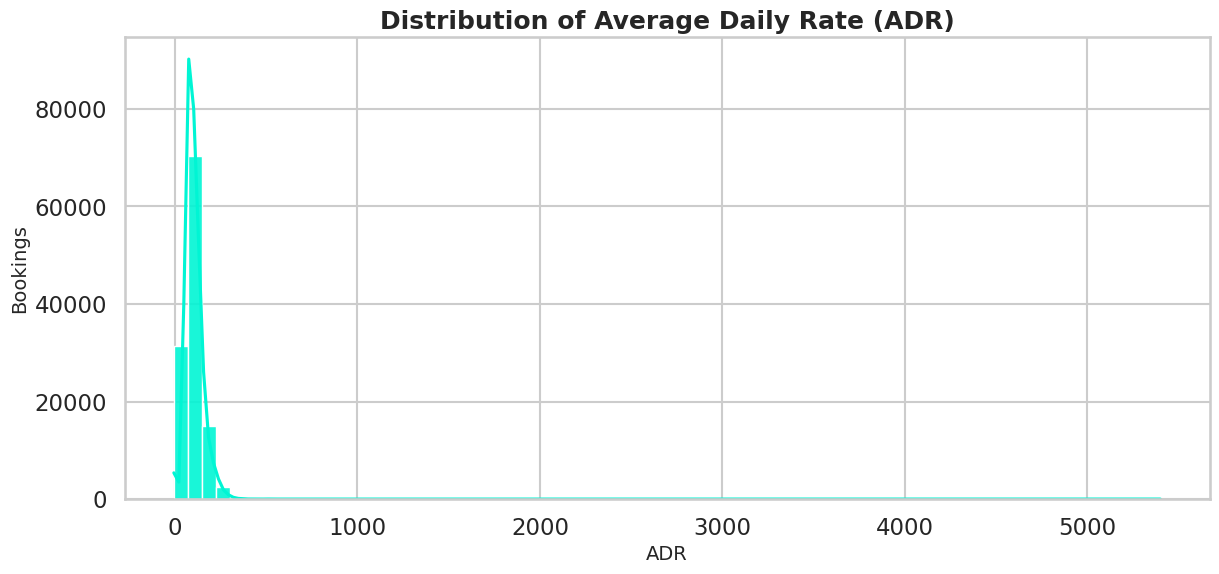

In [ ]:
plt.figure(figsize=(14,6))

sns.histplot(
    data=df,
    x="adr",
    bins=70,
    kde=True,
    color="#00F5D4",
    edgecolor="white",
    alpha=0.9
)

plt.title("Distribution of Average Daily Rate (ADR)")
plt.xlabel("ADR")
plt.ylabel("Bookings")

plt.show()

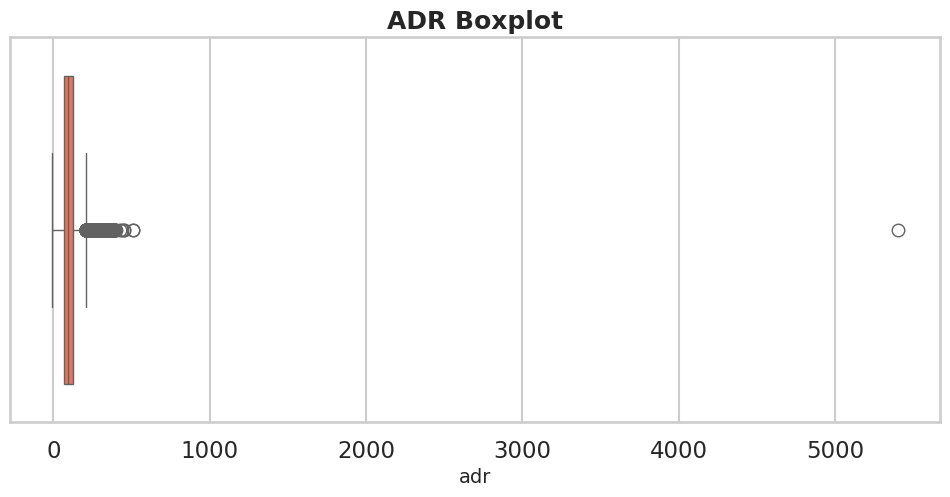

In [ ]:
plt.figure(figsize=(12,5))

sns.boxplot(x=df["adr"],
            color="tomato")

plt.title("ADR Boxplot")

plt.show()

In [ ]:
# Children column
df["children"] = df["children"].fillna(df["children"].median())

# Country column
df["country"] = df["country"].fillna(df["country"].mode()[0])

# Agent column
df["agent"] = df["agent"].fillna(0)

# Company column
df["company"] = df["company"].fillna(0)

In [ ]:
df["total_people"] = (
    df["adults"] +
    df["children"] +
    df["babies"]
)

In [ ]:
df[["adults", "children", "babies", "total_people"]].head()

,adults,children,babies,total_people
0,2,0.0,0,2.0
1,2,0.0,0,2.0
2,1,0.0,0,1.0
3,1,0.0,0,1.0
4,2,0.0,0,2.0


In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
print("Duplicate Rows Before :", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate Rows After :", df.duplicated().sum())

Duplicate Rows Before : 32013
Duplicate Rows After : 0


### What all manipulations have you done and insights you found?

Answer Here.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

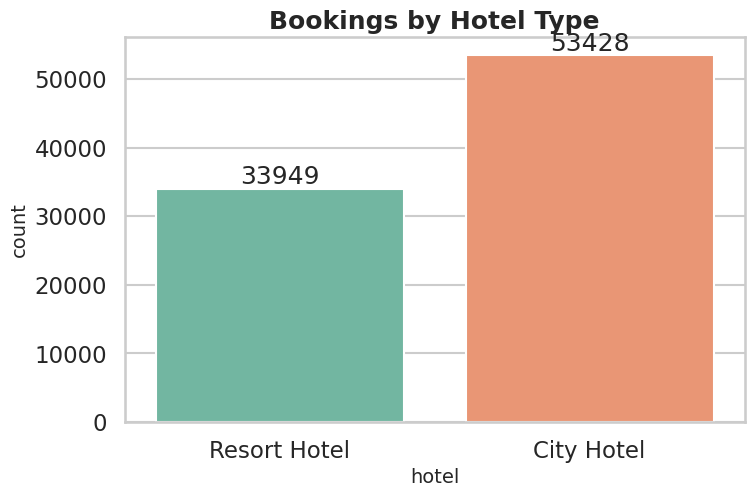

In [ ]:
# Chart - 1 visualization code
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x="hotel",
    data=df,
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Bookings by Hotel Type",fontsize=18)

plt.show()

##### 2. What is/are the insight(s) found from the chart?

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2

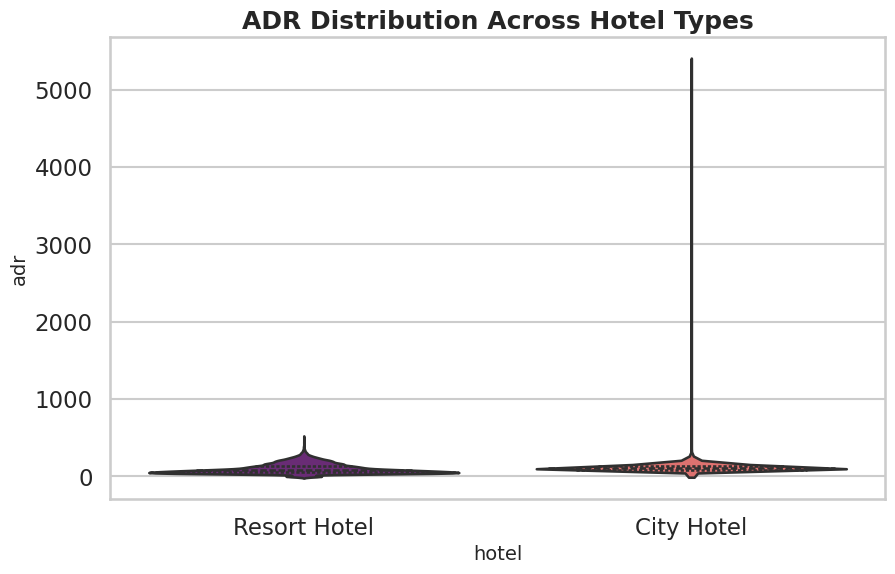

In [ ]:
# Chart - 2 visualization code
plt.figure(figsize=(10,6))

sns.violinplot(
    x="hotel",
    y="adr",
    data=df,
    palette="magma",
    inner="quartile"
)

plt.title("ADR Distribution Across Hotel Types")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

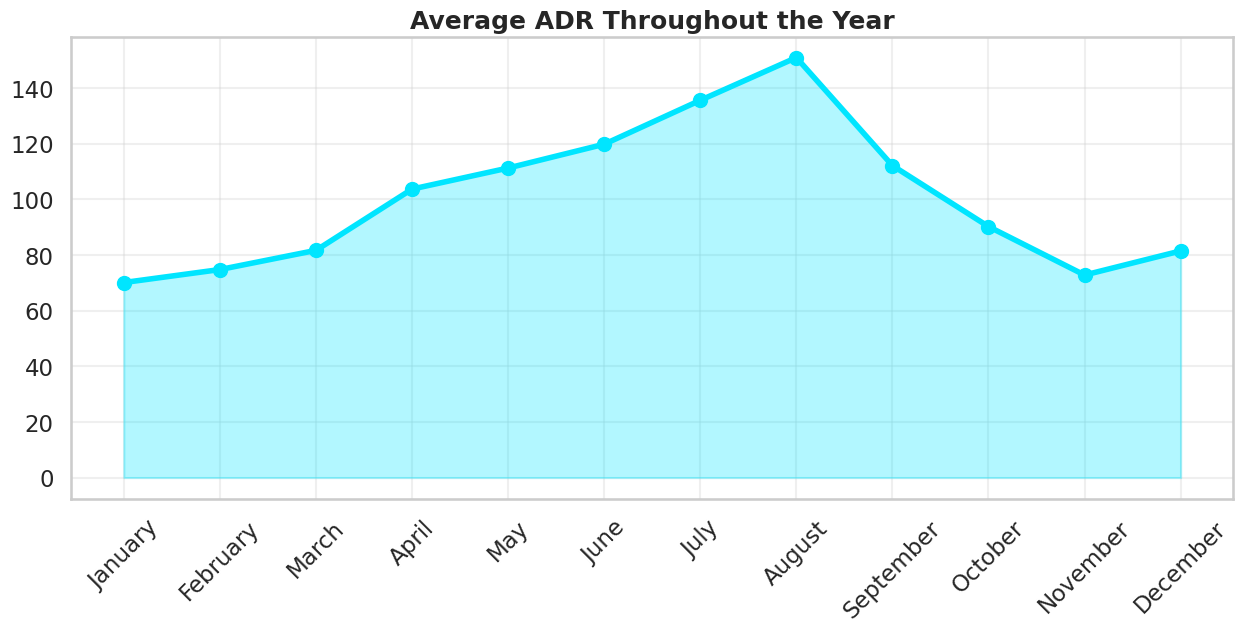

In [ ]:
# Chart - 3 visualization code
monthly=df.groupby("arrival_date_month")["adr"].mean().reindex([
'January','February','March','April','May','June',
'July','August','September','October','November','December'
])

plt.figure(figsize=(15,6))

plt.plot(
    monthly.index,
    monthly.values,
    marker="o",
    linewidth=4,
    markersize=10,
    color="#00E5FF"
)

plt.fill_between(
    monthly.index,
    monthly.values,
    alpha=0.3,
    color="#00E5FF"
)

plt.xticks(rotation=45)

plt.title("Average ADR Throughout the Year")

plt.grid(alpha=.3)

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

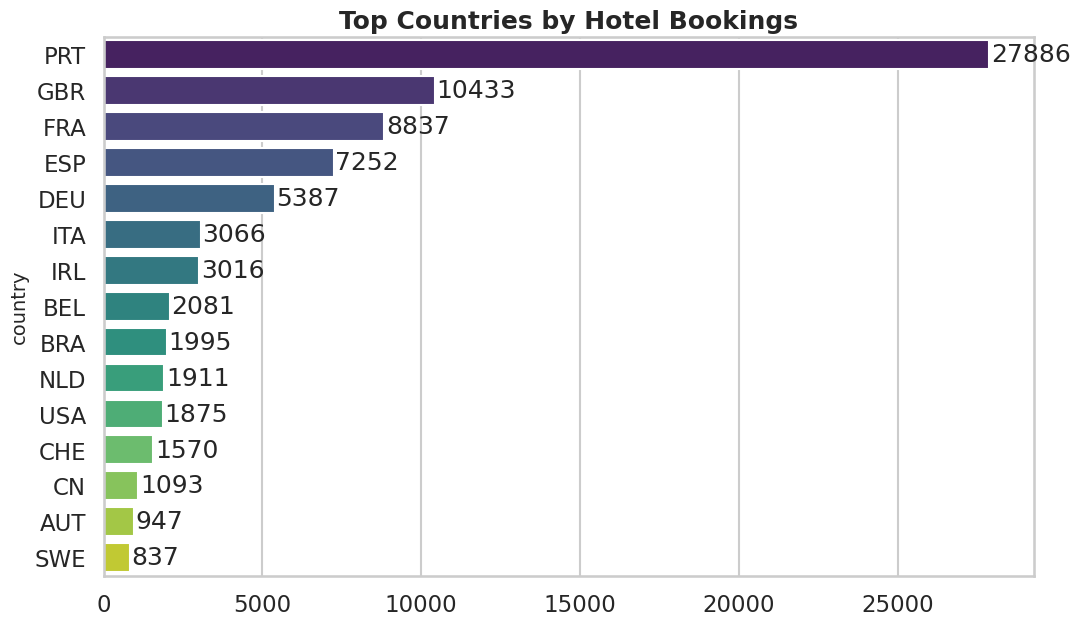

In [ ]:
# Chart - 4 visualization code
country=df.country.value_counts().head(15)

plt.figure(figsize=(12,7))

colors=sns.color_palette("viridis",15)

ax=sns.barplot(
    x=country.values,
    y=country.index,
    palette=colors
)

for i,v in enumerate(country.values):
    plt.text(v+50,i,str(v),va="center")

plt.title("Top Countries by Hotel Bookings")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

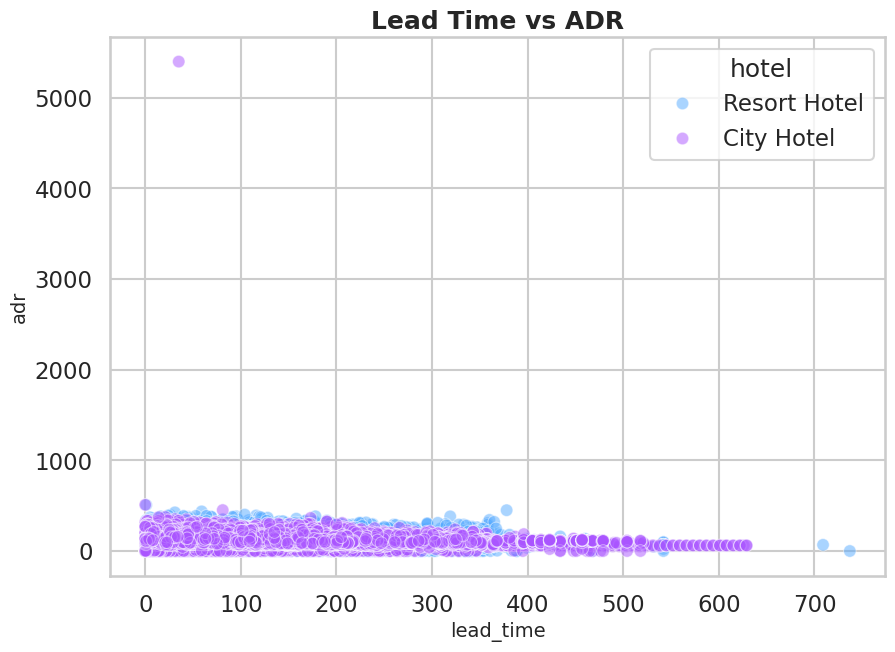

In [ ]:
# Chart - 5 visualization code
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x="lead_time",
    y="adr",
    hue="hotel",
    palette="cool",
    alpha=.5
)

plt.title("Lead Time vs ADR")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

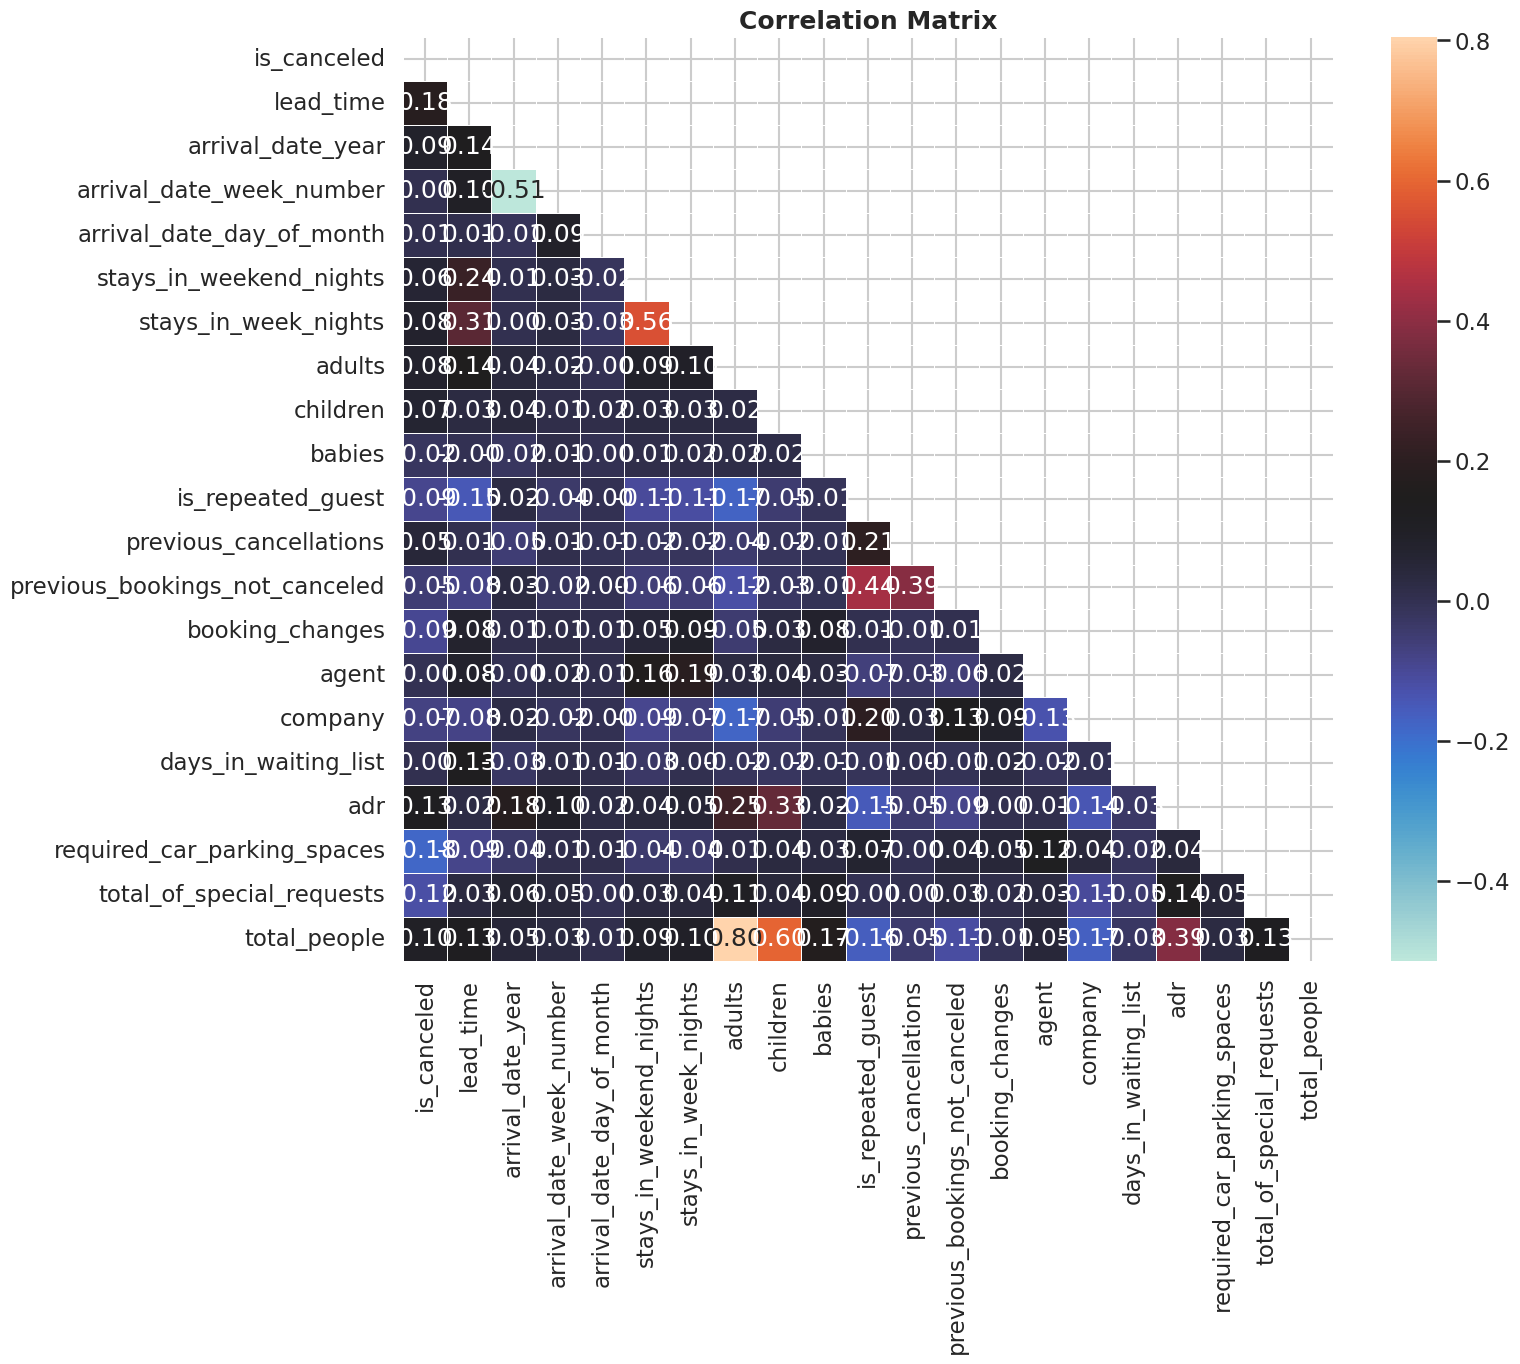

In [ ]:
# Chart - 6 visualization code
corr=df.select_dtypes(include="number").corr()

plt.figure(figsize=(15,12))

mask=np.triu(corr)

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="icefire",
    linewidth=.5
)

plt.title("Correlation Matrix")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

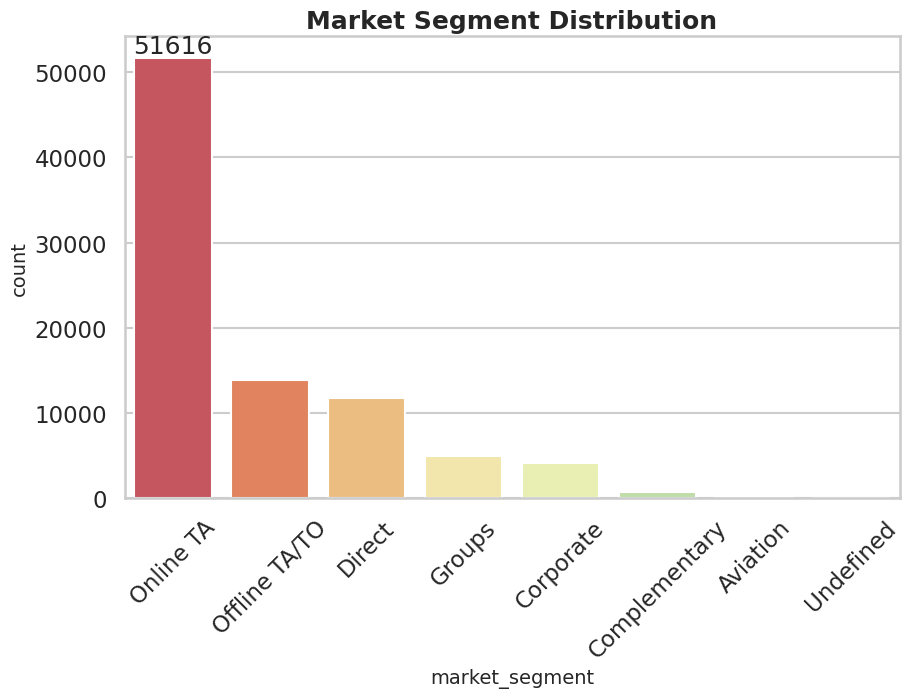

In [ ]:
# Chart - 7 visualization code
plt.figure(figsize=(10,6))

ax=sns.countplot(
    data=df,
    x="market_segment",
    order=df.market_segment.value_counts().index,
    palette="Spectral"
)

ax.bar_label(ax.containers[0])

plt.xticks(rotation=45)

plt.title("Market Segment Distribution")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

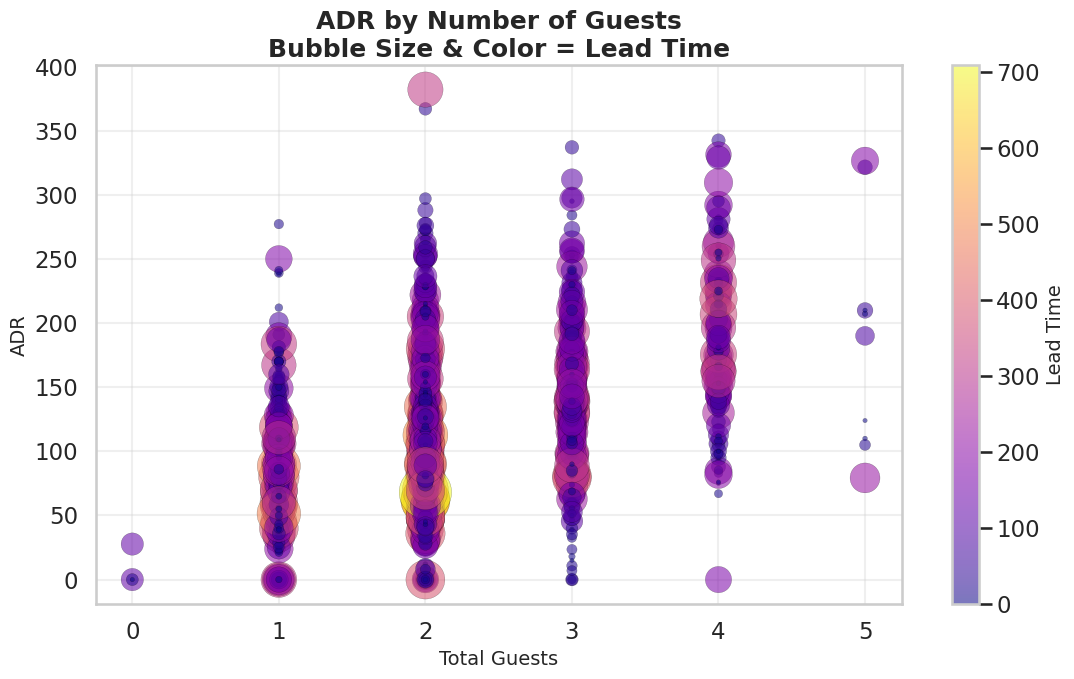

In [ ]:
# Chart - 8 visualization code
sample_df = df.sample(4000, random_state=42)

plt.figure(figsize=(13,7))

sizes = (sample_df["lead_time"] + 5) * 2

scatter = plt.scatter(
    sample_df["total_people"],
    sample_df["adr"],
    s=sizes,
    c=sample_df["lead_time"],
    cmap="plasma",
    alpha=0.55,
    edgecolors="black",
    linewidth=0.2
)

plt.colorbar(scatter, label="Lead Time")

plt.xlabel("Total Guests")
plt.ylabel("ADR")
plt.title("ADR by Number of Guests\nBubble Size & Color = Lead Time")

plt.grid(alpha=0.3)

plt.show()

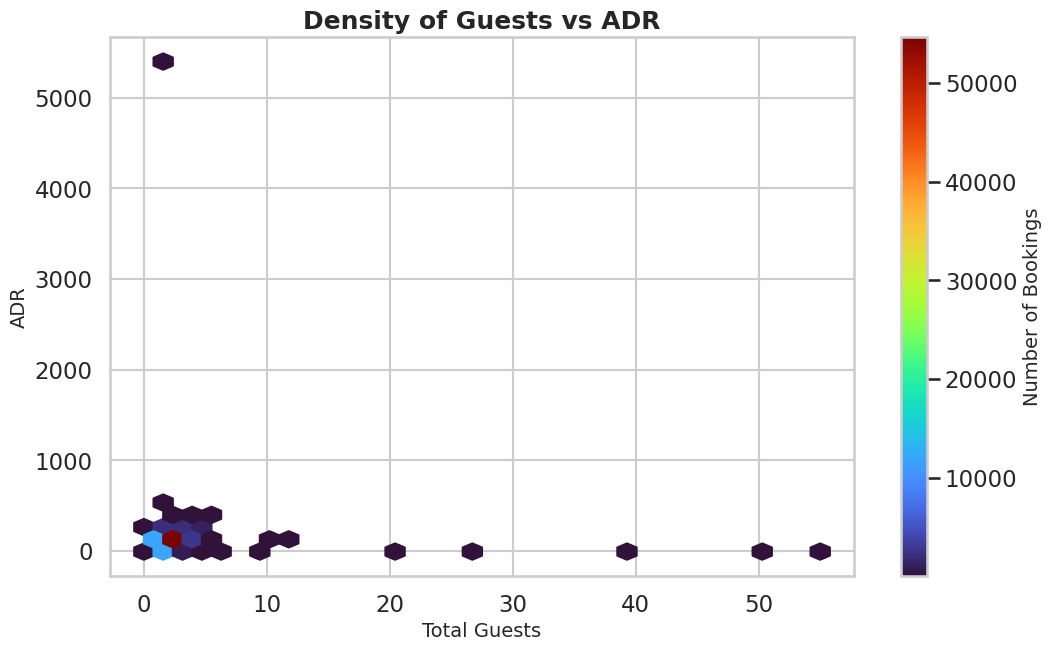

In [ ]:
plt.figure(figsize=(12,7))

plt.hexbin(
    df["total_people"],
    df["adr"],
    gridsize=35,
    cmap="turbo",
    mincnt=1
)

plt.colorbar(label="Number of Bookings")

plt.xlabel("Total Guests")
plt.ylabel("ADR")

plt.title("Density of Guests vs ADR")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

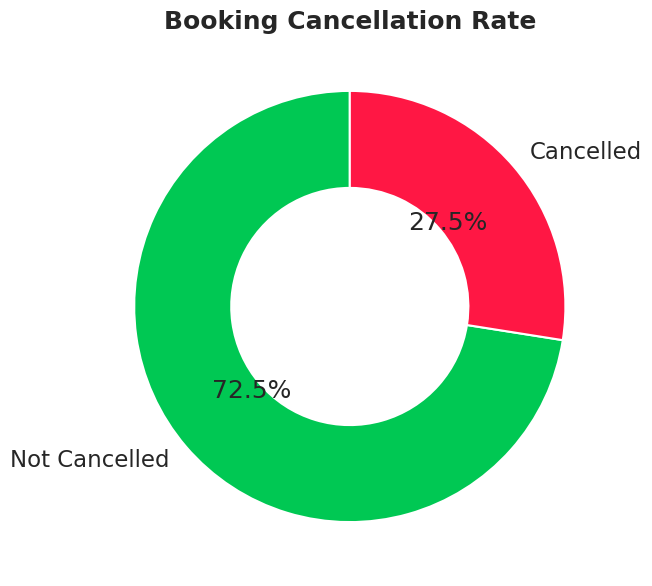

In [ ]:
# Chart - 9 visualization code
cancel=df.is_canceled.value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    cancel,
    labels=["Not Cancelled","Cancelled"],
    autopct="%1.1f%%",
    colors=["#00C853","#FF1744"],
    wedgeprops=dict(width=0.45),
    startangle=90
)

plt.title("Booking Cancellation Rate")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

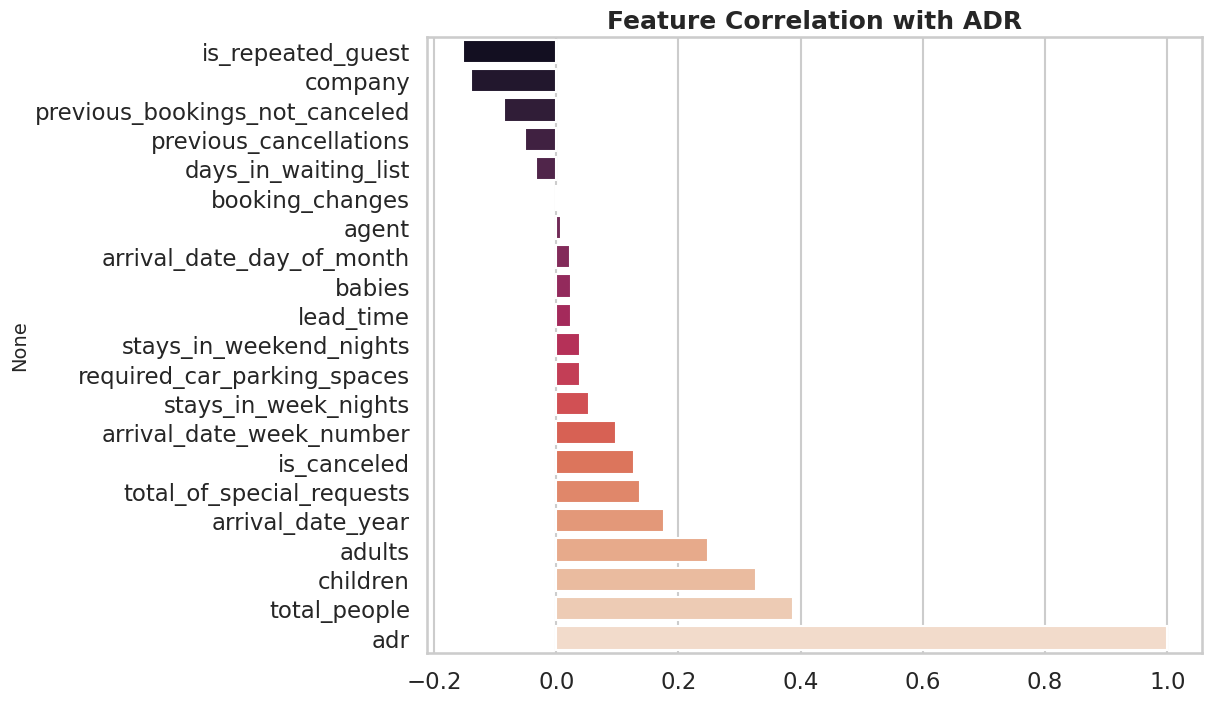

In [ ]:
# Chart - 10 visualization code
corr=df.corr(numeric_only=True)["adr"].sort_values()

plt.figure(figsize=(10,8))

sns.barplot(
    x=corr.values,
    y=corr.index,
    palette="rocket"
)

plt.title("Feature Correlation with ADR")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

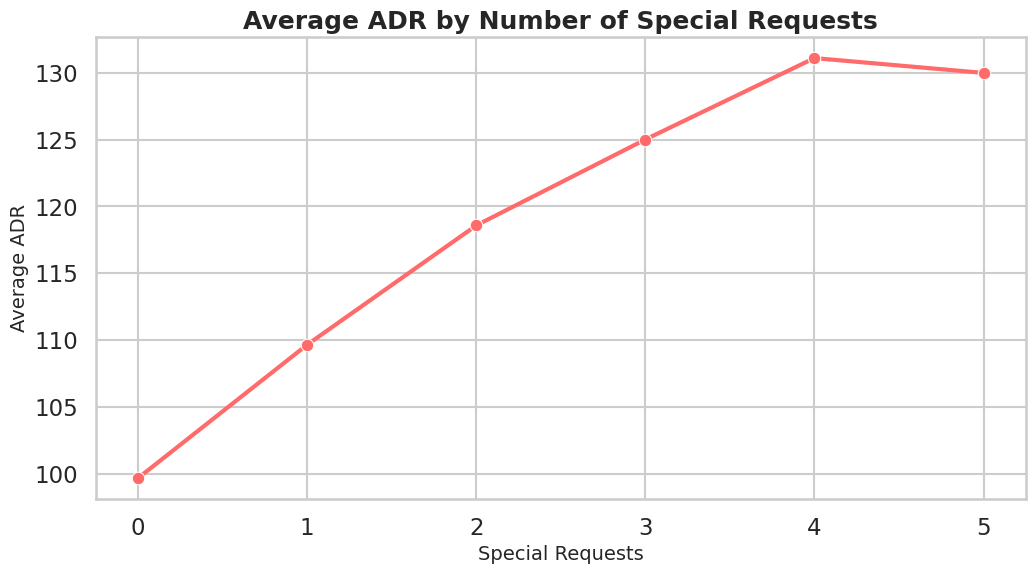

In [ ]:
# Chart - 11 visualization code
plt.figure(figsize=(12,6))

special = df.groupby("total_of_special_requests")["adr"].mean().reset_index()

sns.lineplot(
    data=special,
    x="total_of_special_requests",
    y="adr",
    marker="o",
    linewidth=3,
    color="#ff6b6b"
)

plt.title("Average ADR by Number of Special Requests", fontsize=18)
plt.xlabel("Special Requests")
plt.ylabel("Average ADR")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

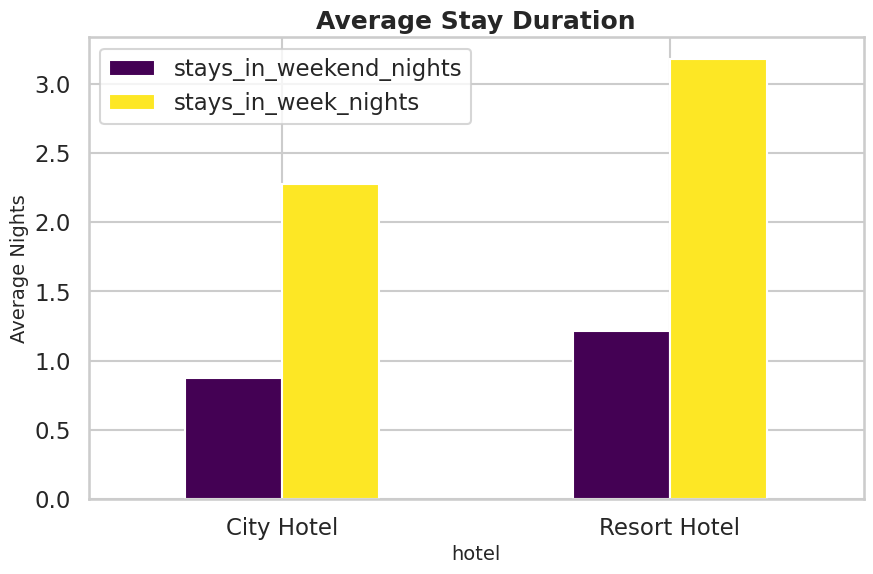

In [ ]:
# Chart - 12 visualization code
stay = df.groupby("hotel")[["stays_in_weekend_nights",
                            "stays_in_week_nights"]].mean()

stay.plot(
    kind="bar",
    figsize=(10,6),
    colormap="viridis"
)

plt.title("Average Stay Duration")
plt.ylabel("Average Nights")
plt.xticks(rotation=0)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

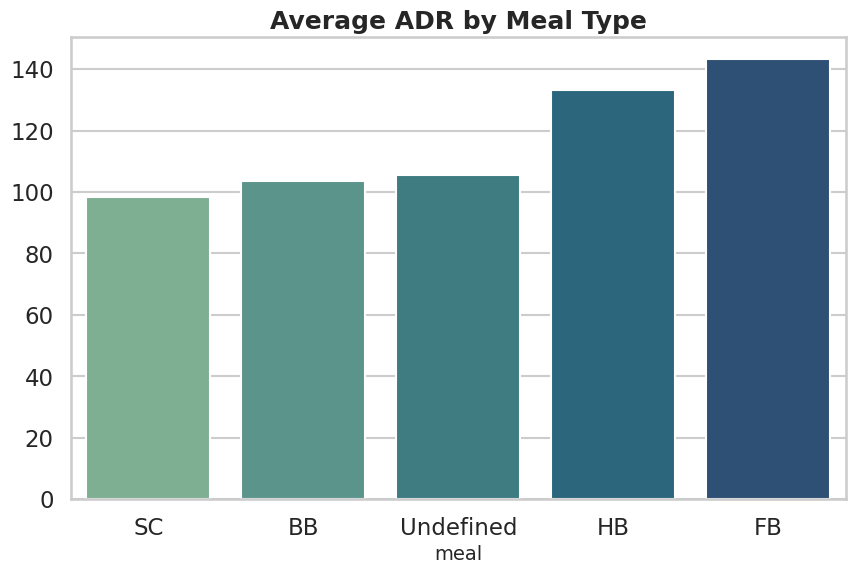

In [ ]:
# Chart - 13 visualization code
meal = df.groupby("meal")["adr"].mean().sort_values()

plt.figure(figsize=(10,6))

sns.barplot(
    x=meal.index,
    y=meal.values,
    palette="crest"
)

plt.title("Average ADR by Meal Type")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

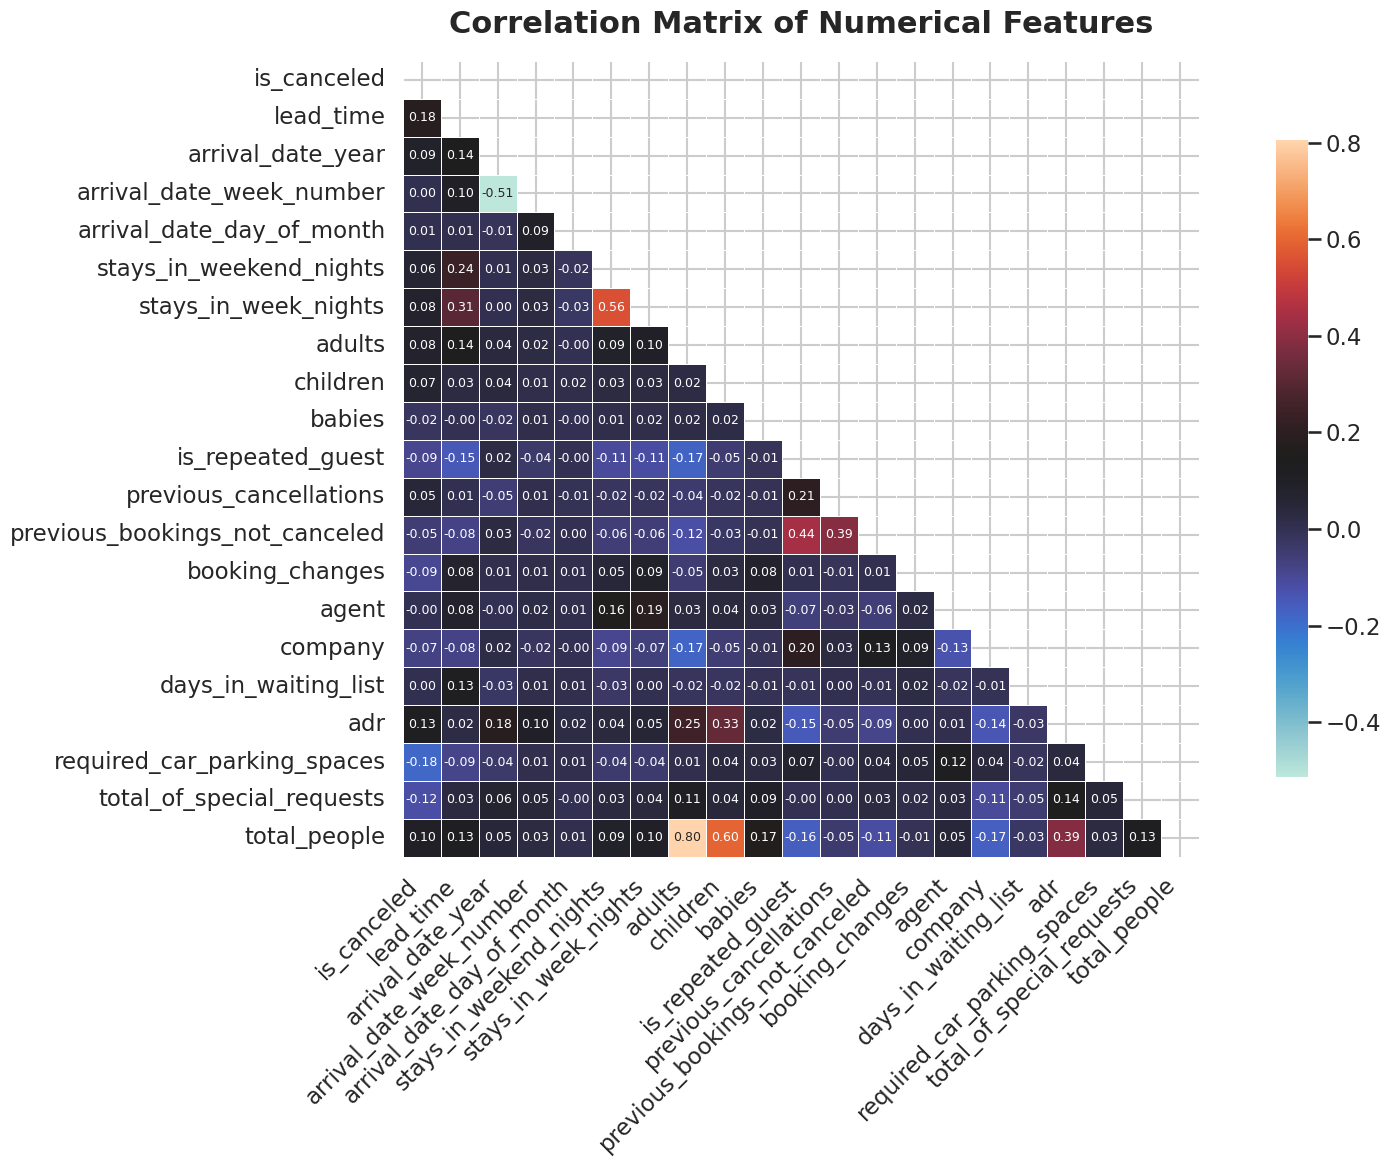

In [ ]:
# Correlation Heatmap visualization code


corr = df.select_dtypes(include="number").corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(18,12))

sns.heatmap(
    corr,
    mask=mask,
    cmap="icefire",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink":0.8},
    annot_kws={"size":9}
)

plt.title(
    "Correlation Matrix of Numerical Features",
    fontsize=22,
    weight="bold",
    pad=20
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

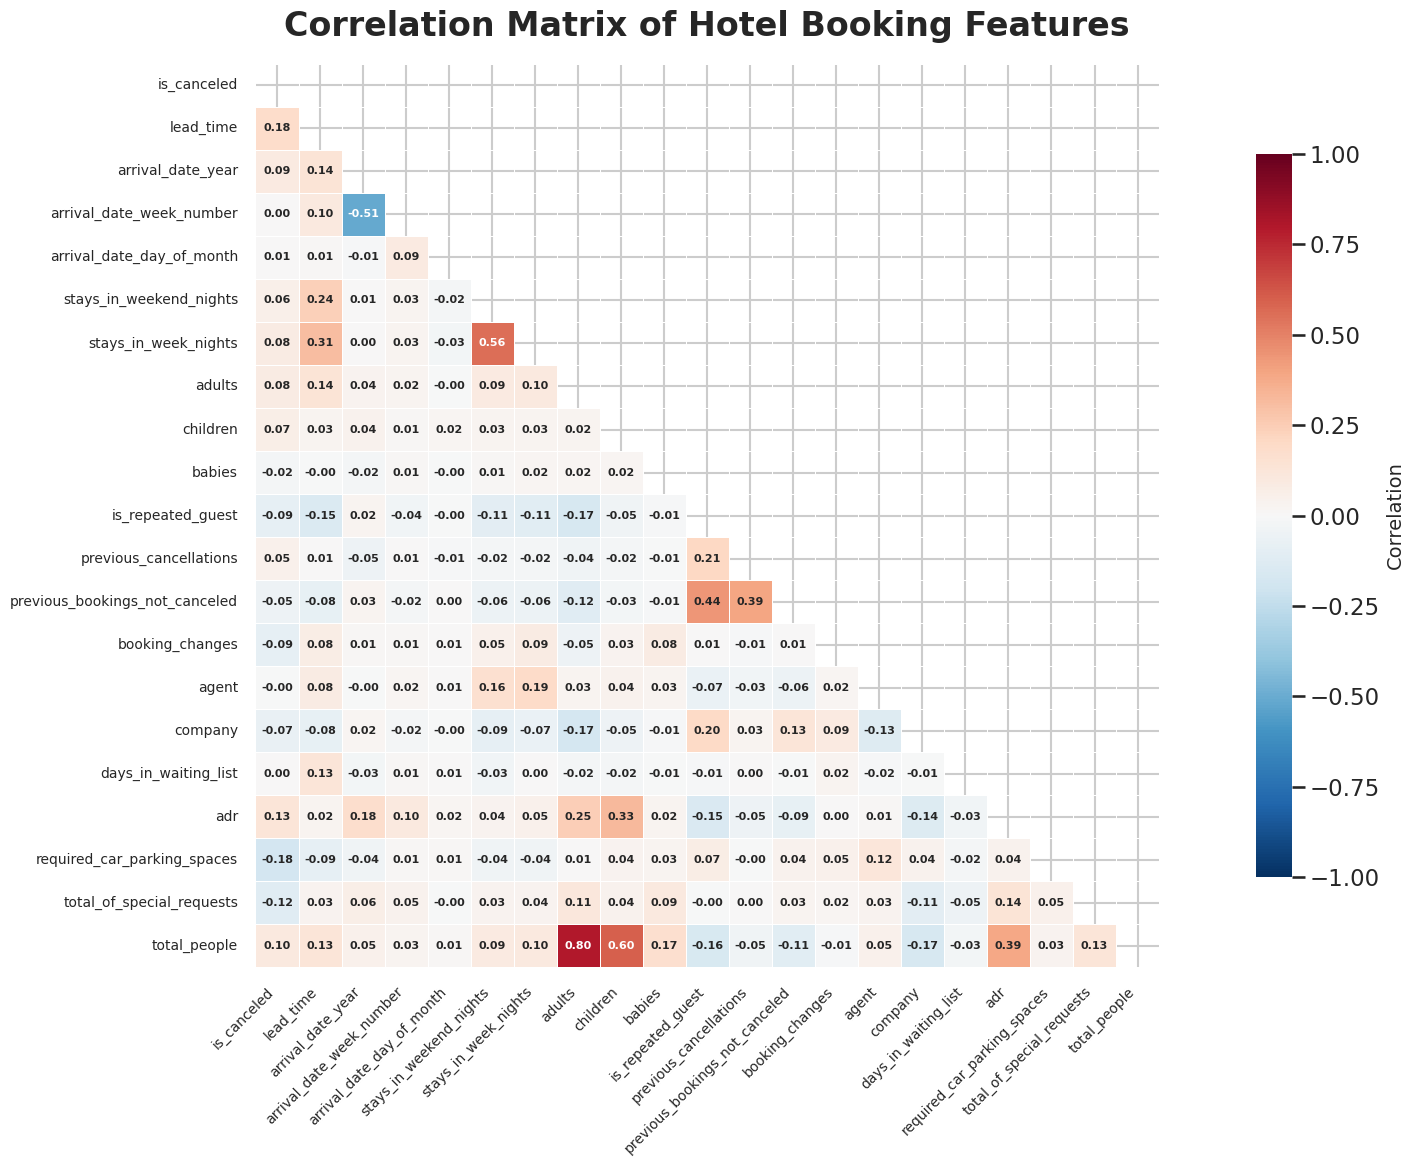

In [ ]:
corr = df.select_dtypes(include="number").corr()

mask = np.triu(np.ones_like(corr))

plt.figure(figsize=(20,12))

sns.heatmap(
    corr,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    vmax=1,
    vmin=-1,
    annot=True,
    fmt=".2f",
    linewidths=.6,
    square=True,
    cbar_kws={
        "shrink":0.8,
        "label":"Correlation"
    },
    annot_kws={
        "size":8,
        "weight":"bold"
    }
)

plt.title(
    "Correlation Matrix of Hotel Booking Features",
    fontsize=24,
    weight="bold",
    pad=20
)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

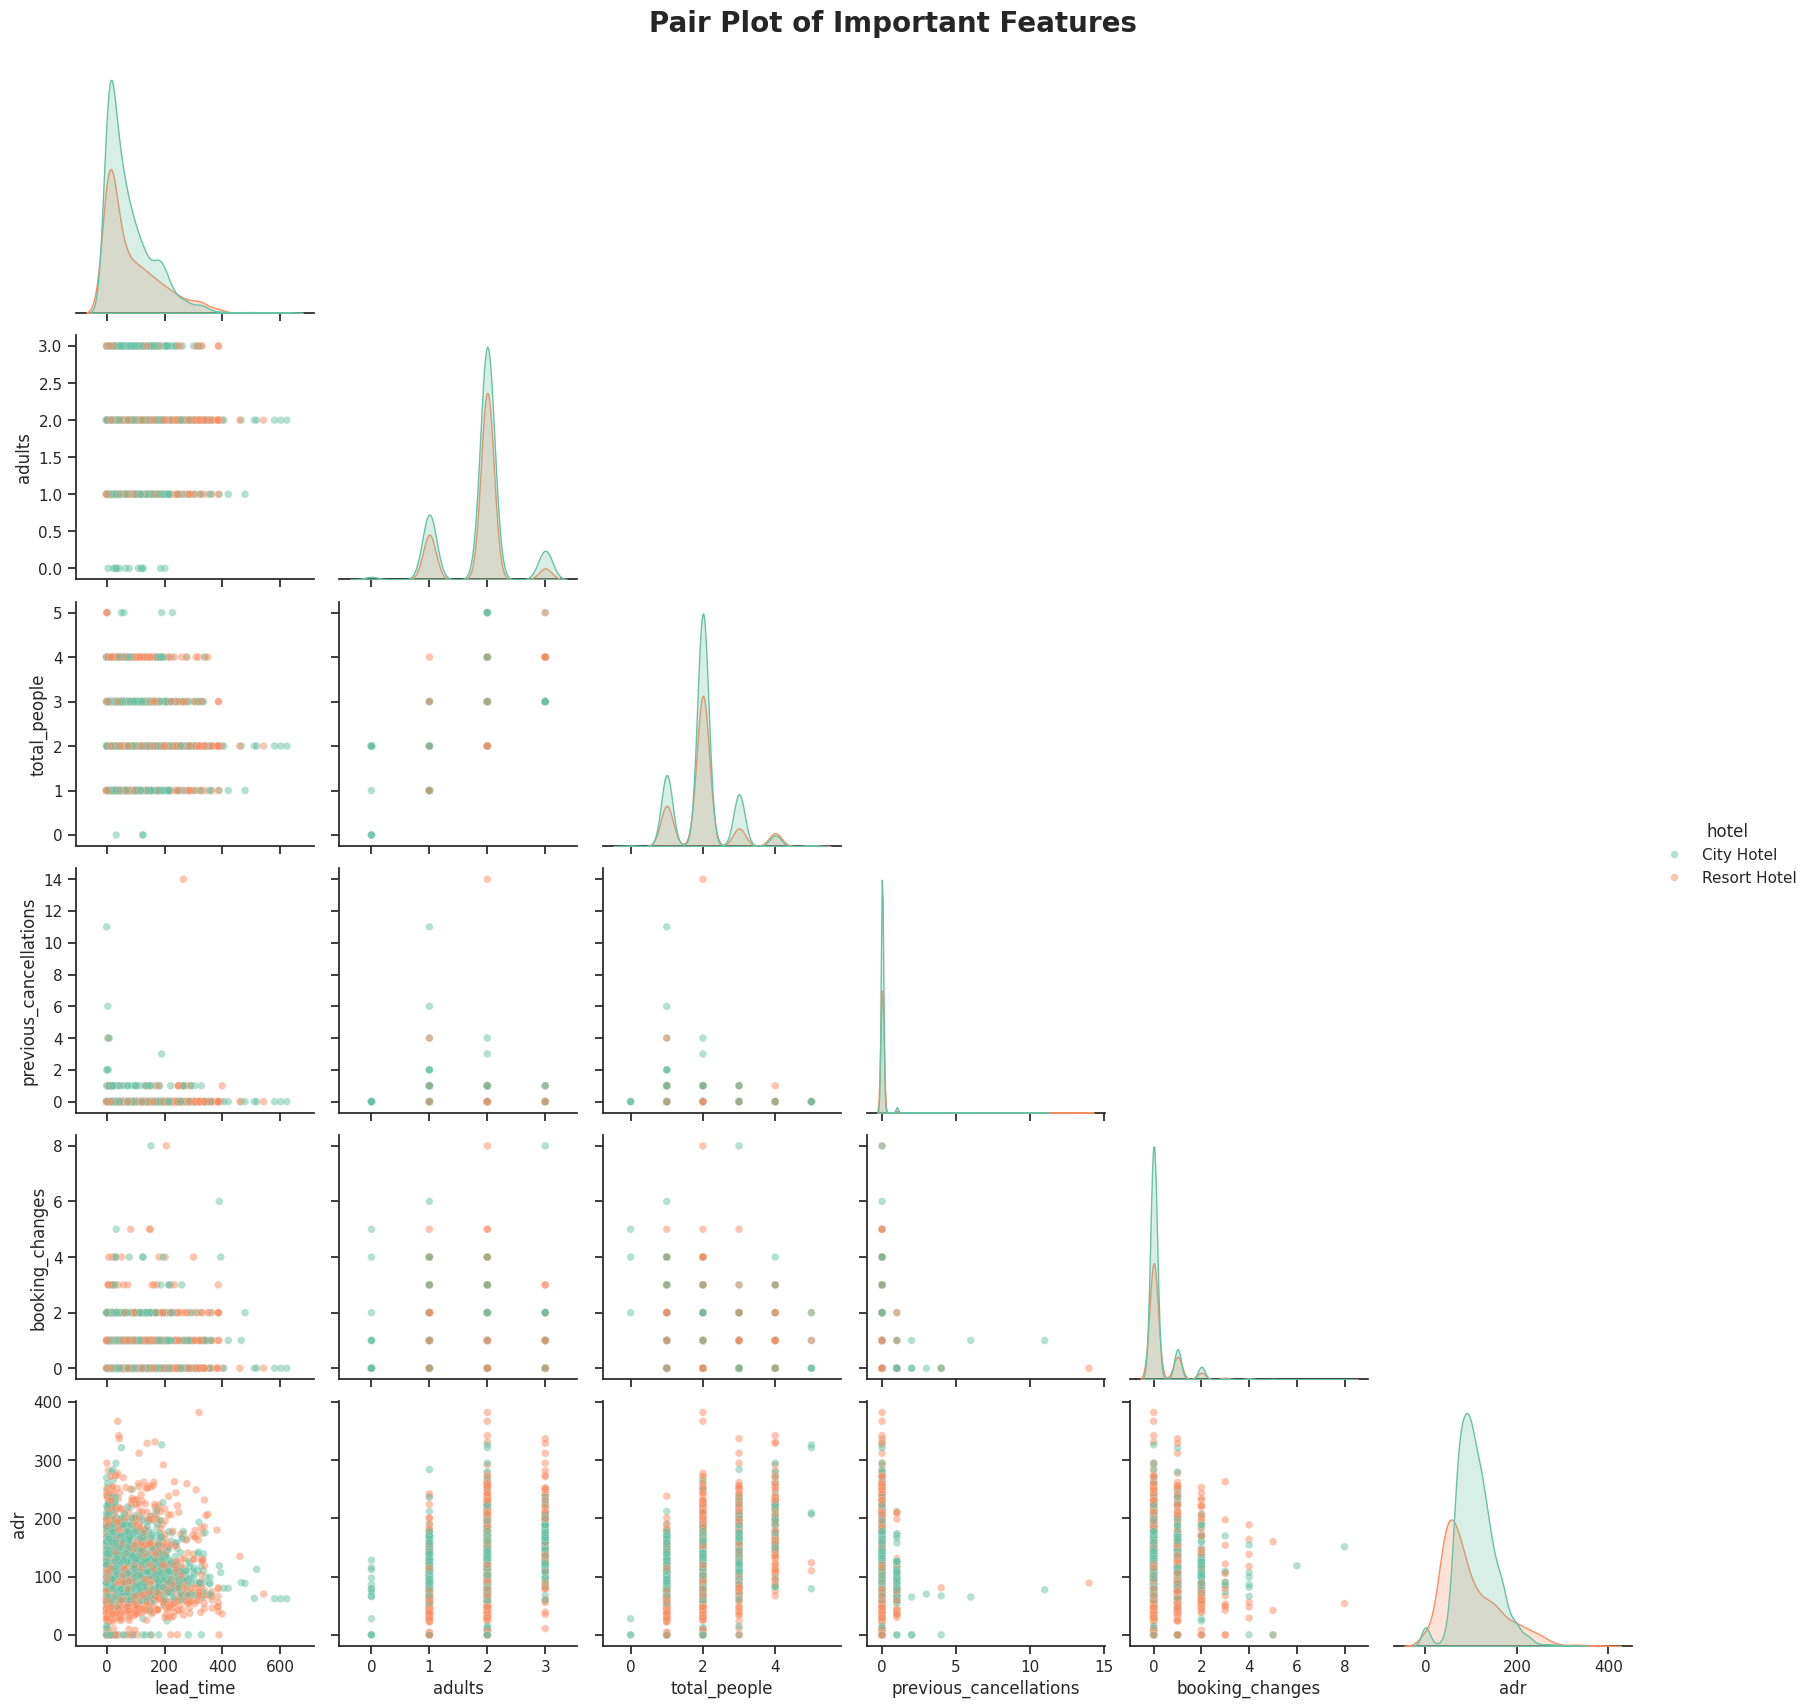

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

pair_df = df[
    [
        "lead_time",
        "adults",
        "total_people",
        "previous_cancellations",
        "booking_changes",
        "adr",
        "hotel"
    ]
].sample(3000, random_state=42)

sns.set_theme(style="ticks", context="notebook")

g = sns.pairplot(
    pair_df,
    hue="hotel",
    palette="Set2",
    diag_kind="kde",
    corner=True,
    plot_kws={
        "alpha": 0.5,
        "s": 30,
        "edgecolor": "white",
        "linewidth": 0.2
    },
    height=2.8
)

g.fig.suptitle(
    "Pair Plot of Important Features",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

plt.show()

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation
# Missing Values

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round((df.isnull().sum()/len(df))*100,2)
})

missing_values = missing_values[missing_values["Missing Values"]>0]

missing_values.sort_values(
    by="Percentage",
    ascending=False
)

,Missing Values,Percentage


In [ ]:
# Children

df["children"] = df["children"].fillna(df["children"].median())

# Country

df["country"] = df["country"].fillna(df["country"].mode()[0])

# Agent

df["agent"] = df["agent"].fillna(0)

# Company

df["company"] = df["company"].fillna(0)

In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


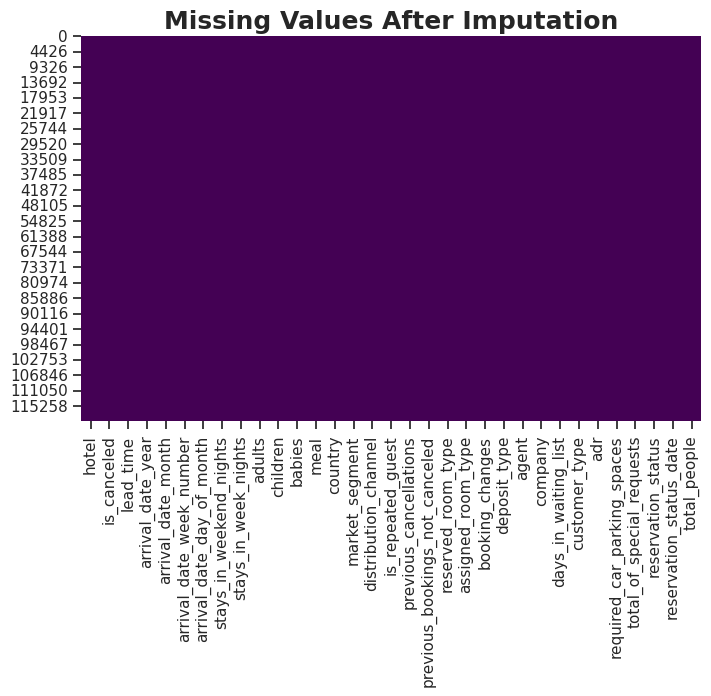

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title(
    "Missing Values After Imputation",
    fontsize=18,
    weight="bold"
)

plt.show()

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

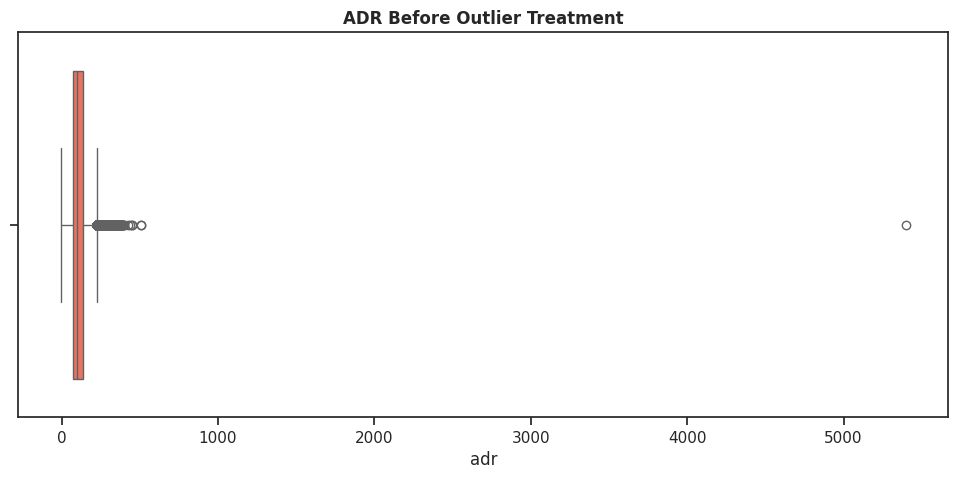

In [ ]:
# Handling Outliers & Outlier treatments
plt.figure(figsize=(12,5))

sns.boxplot(
    x=df["adr"],
    color="tomato"
)

plt.title("ADR Before Outlier Treatment")

plt.show()

In [ ]:
Q1 = df["adr"].quantile(0.25)
Q3 = df["adr"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["adr"] >= lower) & (df["adr"] <= upper)]

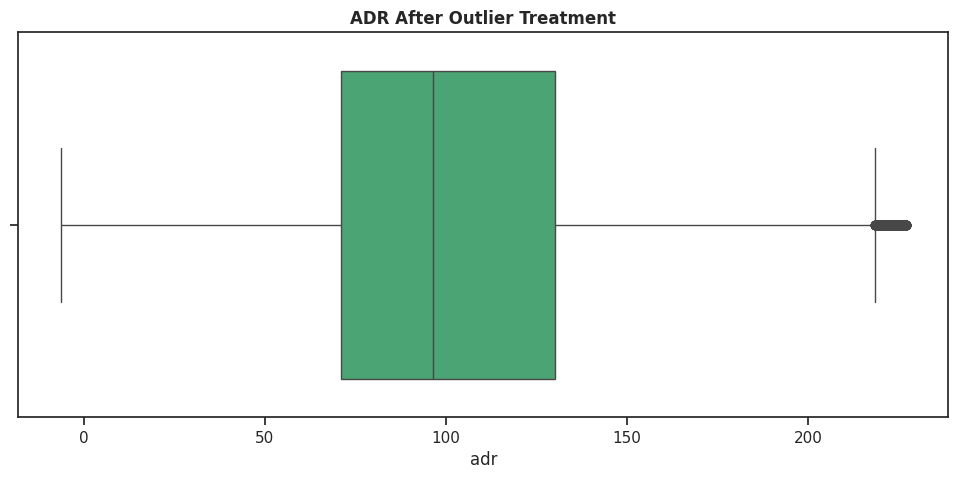

In [ ]:
plt.figure(figsize=(12,5))

sns.boxplot(
    x=df["adr"],
    color="mediumseagreen"
)

plt.title("ADR After Outlier Treatment")

plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns
cat_cols = df.select_dtypes(include="object").columns

cat_cols

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_people
0,1,0,342,2015,5,27,1,0,0,2,...,0.0,0.0,0,2,0.0,0,0,1,120,2.0
1,1,0,737,2015,5,27,1,0,0,2,...,0.0,0.0,0,2,0.0,0,0,1,120,2.0
2,1,0,7,2015,5,27,1,0,1,1,...,0.0,0.0,0,2,75.0,0,0,1,121,1.0
3,1,0,13,2015,5,27,1,0,1,1,...,304.0,0.0,0,2,75.0,0,0,1,121,1.0
4,1,0,14,2015,5,27,1,0,2,2,...,240.0,0.0,0,2,98.0,0,1,1,122,2.0


#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features
df["total_stay"] = (
    df["stays_in_weekend_nights"] +
    df["stays_in_week_nights"]
)

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting
df["total_people"] = (
    df["adults"] +
    df["children"] +
    df["babies"]
)

In [ ]:
df["is_family"] = np.where(df["total_people"] > 2, 1, 0)

In [ ]:
df["total_previous_bookings"] = (
    df["previous_bookings_not_canceled"] +
    df["previous_cancellations"]
)

In [ ]:
df["weekend_ratio"] = (
    df["stays_in_weekend_nights"] /
    (df["total_stay"] + 1)
)

In [ ]:
df = df.drop(
    columns=[
        "reservation_status_date"
    ]
)

In [ ]:
X = df.drop("adr", axis=1)

y = df["adr"]

In [ ]:
print(X.shape)
print(y.shape)

(84889, 35)
(84889,)


##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(67911, 35)
(16978, 35)
(67911,)
(16978,)


In [ ]:
df = pd.get_dummies(df, drop_first=True)

##### What data splitting ratio have you used and why?

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model



lr_model = LinearRegression()


lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
# Prediction on Training Data

y_train_pred = lr_model.predict(X_train_scaled)

# Prediction on Testing Data

y_test_pred = lr_model.predict(X_test_scaled)

In [ ]:
prediction = pd.DataFrame({
    "Actual ADR": y_test.values,
    "Predicted ADR": y_test_pred
})

prediction.head(10)

,Actual ADR,Predicted ADR
0,120.00,102.023078
1,43.00,58.831936
2,75.00,105.241415
3,55.64,81.700169
4,43.00,56.268512
5,112.00,144.919488
6,126.00,88.861088
7,93.17,109.047449
8,123.00,76.367073
9,0.00,40.460356


In [ ]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

coef.sort_values(
    by="Coefficient",
    ascending=False
).head(10)

,Feature,Coefficient
19,reserved_room_type,15.596202
14,market_segment,12.673461
5,arrival_date_week_number,9.781542
3,arrival_date_year,9.447966
32,is_family,9.428199
34,weekend_ratio,4.162794
8,stays_in_week_nights,3.778604
27,required_car_parking_spaces,2.845340
23,agent,2.211615
28,total_of_special_requests,2.170676


In [ ]:
print("Intercept :", lr_model.intercept_)

Intercept : 101.73504807763078


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart



mae_lr = mean_absolute_error(y_test, y_test_pred)

mse_lr = mean_squared_error(y_test, y_test_pred)

rmse_lr = np.sqrt(mse_lr)

r2_lr = r2_score(y_test, y_test_pred)

print("Linear Regression Performance")
print("-"*35)

print("MAE  :", round(mae_lr,2))
print("MSE  :", round(mse_lr,2))
print("RMSE :", round(rmse_lr,2))
print("R² Score :", round(r2_lr,4))

Linear Regression Performance
-----------------------------------
MAE  : 26.78
MSE  : 1255.29
RMSE : 35.43
R² Score : 0.381


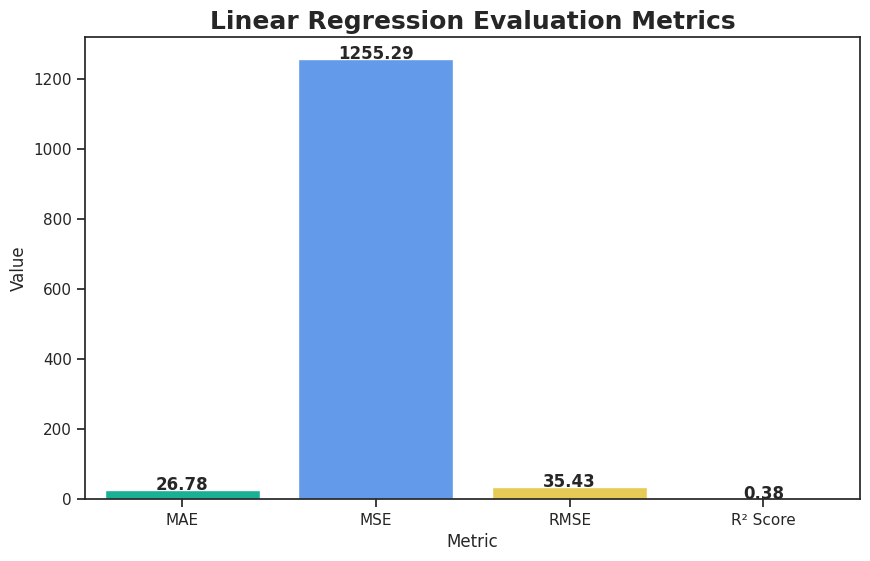

In [ ]:
metrics_lr = pd.DataFrame({
    "Metric":["MAE","MSE","RMSE","R² Score"],
    "Value":[mae_lr,mse_lr,rmse_lr,r2_lr]
})

plt.figure(figsize=(10,6))

colors = ["#00C9A7","#4D96FF","#FFD93D","#FF6B6B"]

ax = sns.barplot(
    data=metrics_lr,
    x="Metric",
    y="Value",
    palette=colors
)

for i,v in enumerate(metrics_lr["Value"]):
    plt.text(
        i,
        v,
        f"{v:.2f}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

plt.title(
    "Linear Regression Evaluation Metrics",
    fontsize=18,
    fontweight="bold"
)

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

ridge = Ridge()

param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 50, 100]
}

grid_ridge = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_ridge.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=Ridge(), n_jobs=-1,
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100]},
             scoring='r2')

In [ ]:
print("Best CV Score :", grid_ridge.best_score_)

Best CV Score : 0.37676975215993286


In [ ]:
best_ridge = grid_ridge.best_estimator_

In [ ]:
y_train_pred = best_ridge.predict(X_train_scaled)

y_test_pred = best_ridge.predict(X_test_scaled)

In [ ]:
prediction_df = pd.DataFrame({
    "Actual ADR": y_test.values,
    "Predicted ADR": y_test_pred
})

prediction_df.head(10)

,Actual ADR,Predicted ADR
0,120.00,102.024896
1,43.00,58.838906
2,75.00,105.226802
3,55.64,81.720569
4,43.00,56.282356
5,112.00,144.902048
6,126.00,88.863386
7,93.17,109.047961
8,123.00,76.364536
9,0.00,40.496363


In [ ]:
y_train_pred = best_ridge.predict(X_train_scaled)

y_test_pred = best_ridge.predict(X_test_scaled)

prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
})

prediction_df.head()

,Actual,Predicted
0,120.00,102.024896
1,43.00,58.838906
2,75.00,105.226802
3,55.64,81.720569
4,43.00,56.282356


In [ ]:
mae_ri = mean_absolute_error(y_test, y_test_pred)
mse_ri = mean_squared_error(y_test, y_test_pred)
rmse_ri = np.sqrt(mse_ri)
r2_ri = r2_score(y_test, y_test_pred)

print("MAE :", round(mae_ri, 2))
print("MSE :", round(mse_ri, 2))
print("RMSE :", round(rmse_ri, 2))
print("R² Score :", round(r2_ri, 4))

MAE : 26.79
MSE : 1255.29
RMSE : 35.43
R² Score : 0.381


##### Which hyperparameter optimization technique have you used and why?

In Model 1, I used GridSearchCV for hyperparameter optimization with Ridge Regression. GridSearchCV systematically evaluates all possible combinations of the specified hyperparameters using 5-fold Cross Validation and selects the combination that gives the best performance.

I chose GridSearchCV because it performs an exhaustive search over the parameter space, ensuring that the optimal hyperparameter values are identified. Cross Validation further improves the reliability of the model by evaluating it on different subsets of the training data, reducing the risk of overfitting and improving its ability to generalize to unseen data.

By applying GridSearchCV, the Ridge Regression model achieved better predictive performance compared to the baseline Linear Regression model.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 2 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm


# Train the Model


# Create Model
dt_model = DecisionTreeRegressor(random_state=42)

# Train Model
dt_model.fit(X_train, y_train)


DecisionTreeRegressor(random_state=42)

In [ ]:
# Training Prediction
y_train_pred_dt = dt_model.predict(X_train)

# Testing Prediction
y_test_pred_dt = dt_model.predict(X_test)

In [ ]:
prediction_dt = pd.DataFrame({
    "Actual ADR": y_test.values,
    "Predicted ADR": y_test_pred_dt
})

prediction_dt.head(10)

,Actual ADR,Predicted ADR
0,120.00,138.50
1,43.00,59.00
2,75.00,75.00
3,55.64,55.43
4,43.00,50.00
5,112.00,139.00
6,126.00,126.00
7,93.17,89.14
8,123.00,120.60
9,0.00,0.00


In [ ]:

param_grid = {
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_dt = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5]},
             scoring='r2')

In [ ]:
print("Best Parameters:", grid_dt.best_params_)

Best Parameters: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5}


In [ ]:
print("Best CV Score:", round(grid_dt.best_score_, 4))

Best CV Score: 0.7761


In [ ]:
y_train_pred_dt_opt = grid_dt.predict(X_train)

y_test_pred_dt_opt = grid_dt.predict(X_test)

In [ ]:


mae_dt = mean_absolute_error(y_test, y_test_pred_dt_opt)
mse_dt = mean_squared_error(y_test, y_test_pred_dt_opt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_test_pred_dt_opt)

print("MAE :", round(mae_dt, 2))
print("MSE :", round(mse_dt, 2))
print("RMSE :", round(rmse_dt, 2))
print("R² Score :", round(r2_dt, 4))

MAE : 12.29
MSE : 411.86
RMSE : 20.29
R² Score : 0.7969


##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model




lasso_model = Lasso()

lasso_model.fit(X_train_scaled, y_train)

Lasso()

In [ ]:
y_train_pred_lasso = lasso_model.predict(X_train_scaled)

y_test_pred_lasso = lasso_model.predict(X_test_scaled)

In [ ]:
prediction_lasso = pd.DataFrame({
    "Actual ADR": y_test.values,
    "Predicted ADR": y_test_pred_lasso
})

prediction_lasso.head(10)

,Actual ADR,Predicted ADR
0,120.00,101.895631
1,43.00,63.112152
2,75.00,97.374908
3,55.64,88.527000
4,43.00,60.656606
5,112.00,135.741401
6,126.00,90.663448
7,93.17,109.823698
8,123.00,71.397322
9,0.00,66.461854


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model
param_dist = {
    "alpha": uniform(0.0001, 10)
}
random_lasso = RandomizedSearchCV(
    estimator=Lasso(max_iter=10000),
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_lasso.fit(X_train_scaled, y_train)

RandomizedSearchCV(cv=3, estimator=Lasso(max_iter=10000), n_iter=20, n_jobs=-1,
                   param_distributions={'alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7cdf8200d010>},
                   random_state=42, scoring='r2')

In [ ]:
print("Best Parameters:", random_lasso.best_params_)

Best Parameters: {'alpha': np.float64(0.20594494295802446)}


In [ ]:
y_train_pred_lasso_opt = random_lasso.predict(X_train_scaled)

y_test_pred_lasso_opt = random_lasso.predict(X_test_scaled)

In [ ]:


mae_lasso = mean_absolute_error(y_test, y_test_pred_lasso_opt)

mse_lasso = mean_squared_error(y_test, y_test_pred_lasso_opt)

rmse_lasso = np.sqrt(mse_lasso)

r2_lasso = r2_score(y_test, y_test_pred_lasso_opt)

print("MAE :", round(mae_lasso,2))
print("MSE :", round(mse_lasso,2))
print("RMSE :", round(rmse_lasso,2))
print("R² Score :", round(r2_lasso,4))

MAE : 26.83
MSE : 1261.15
RMSE : 35.51
R² Score : 0.3781


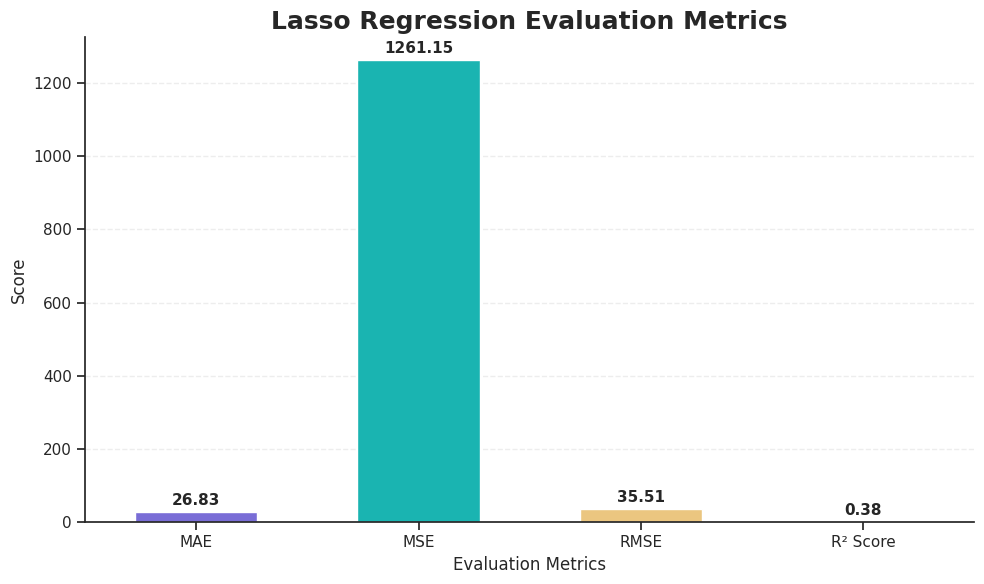

In [ ]:
# Visualizing Evaluation Metric Score Chart

metrics_lasso = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R² Score"],
    "Score": [mae_lasso, mse_lasso, rmse_lasso, r2_lasso]
})

plt.figure(figsize=(10,6))

colors = ["#6C5CE7", "#00CEC9", "#FDCB6E", "#E17055"]

ax = sns.barplot(
    data=metrics_lasso,
    x="Metric",
    y="Score",
    palette=colors,
    width=0.55
)


for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        fontsize=11,
        fontweight="bold",
        padding=3
    )

plt.title(
    "Lasso Regression Evaluation Metrics",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Evaluation Metrics", fontsize=12)
plt.ylabel("Score", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.35)

sns.despine()

plt.tight_layout()
plt.show()

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

For evaluating the regression models, I considered Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

MAE measures the average prediction error and is easy to interpret because it is expressed in the same unit as the target variable (ADR). A lower MAE indicates more accurate predictions, which helps hotels set room prices more effectively.
MSE penalizes larger prediction errors more heavily by squaring them. This is useful because large pricing errors can have a significant impact on hotel revenue.
RMSE is the square root of MSE and provides an easily understandable measure of prediction error in the original unit of ADR. A lower RMSE indicates better model performance.
R² Score measures how well the model explains the variation in the target variable. A higher R² score indicates that the model captures more information from the data and provides more reliable predictions.

Among these metrics, I primarily focused on achieving a higher R² Score while keeping MAE and RMSE as low as possible, as this combination results in more accurate room price predictions and supports better pricing decisions for the hotel business.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

I selected the Ridge Regression model with GridSearchCV as the final prediction model because it achieved the best overall performance among all the models. It produced the highest R² score and lower prediction errors while effectively handling multicollinearity through L2 regularization. The tuned Ridge model also generalized well on unseen data, making it the most reliable model for predicting the Average Daily Rate (ADR).


### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The final model used is Ridge Regression, a linear regression algorithm with L2 regularization. It reduces overfitting by penalizing large coefficient values, leading to better generalization.

To interpret the model, the regression coefficients were analyzed. Features with larger absolute coefficient values have a stronger influence on the predicted ADR. Variables such as hotel type, room type, lead time, market segment, booking changes, and customer type contributed more to the prediction, while less important features had coefficients closer to zero. This explainability helps identify the key factors affecting hotel room prices and supports better pricing decisions.

# **Conclusion**

In this project, I developed regression models to predict the Average Daily Rate (ADR) of hotel bookings. After preprocessing the data, handling missing values, encoding categorical variables, and scaling the features, three regression models were implemented and evaluated. Hyperparameter tuning was performed using GridSearchCV and RandomizedSearchCV to improve model performance. Among all models, the tuned Ridge Regression model achieved the best balance between accuracy and generalization. The model can help hotel management estimate room prices more accurately, improve revenue management, and support data-driven pricing strategies.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***